# Hot Strip Rolling Process - Exploratory Data Analysis (EDA)

## Project Overview & Objectives
This notebook performs an Exploratory Data Analysis (EDA) on industrial process data from a **Hot Strip Mill (HSM)**. In a modern steel plant ,hot strip rolling transforms heated steel slabs into thin, uniform steel strips through successive rolling passes under controlled temperature, speed, deformation, and lubrication conditions.

### Dataset Overview
The dataset contains **1,000 process records** capturing key operating parameters, metallurgical properties, roll geometry, cooling/lubrication conditions, and hydraulic forces:
- **Thermal Parameters**: Entry temperature, Exit temperature
- **Kinematic & Geometric Parameters**: Rolling speed, Strip thickness, Roll diameter
- **Deformation Mechanics**: Reduction ratio, Strain rate, Deformation resistance
- **Interface & Equipment Parameters**: Friction coefficient, Lubrication type (and encoded), Bending force
- **Material Specifications**: Material grade (and encoded)

### Objective of this EDA
The goal of this EDA is to examine process data distributions, evaluate operational boundaries, detect anomalies, analyze interactions between rolling variables, and draw actionable metallurgical and operational insights relevant to hot strip mill operations.

### Industrial Relevance to Steel Manufacturing
In hot rolling mills:
1. **Quality Control**: Strip thickness uniformity, surface finish, and metallurgical phase transitions depend heavily on precise control of entry/exit temperatures and roll bending forces.
2. **Energy & Equipment Protection**: Higher deformation resistance and reduction ratios demand greater roll forces and power; optimization reduces equipment wear and energy consumption.
3. **Process Stability**: Proper lubrication reduces friction and roll wear while maintaining stable strip traction during rolling passes.

## Stage 1: Dataset Understanding & Initial Cleaning



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print("libraries successfully imported!")

libraries successfully imported!


### 2. Loading the Dataset


In [3]:
df = pd.read_csv('hot_strip_rolling_data.csv')

df.head()

,entry_temperature,exit_temperature,rolling_speed,strip_thickness,material_grade,deformation_resistance,friction_coefficient,roll_diameter,reduction_ratio,strain_rate,lubrication_type,material_grade_encoded,lubrication_type_encoded,bending_force
0,1174.84,941.98,2.72,24.54,A36,154.86,0.245,653.22,0.36,0.58,oil,0,1,1222.80
1,1143.09,927.74,1.70,28.45,A36,108.36,0.215,640.43,0.30,0.80,oil,0,1,1089.33
2,1182.38,901.79,2.55,32.06,A36,161.06,0.230,668.79,0.36,0.74,water-based,0,2,1224.46
3,1226.15,880.59,1.83,22.06,AISI 304,139.04,0.106,647.60,0.40,0.66,dry,1,0,1101.68
4,1138.29,920.95,3.92,28.71,SS400,188.47,0.224,656.15,0.33,0.92,oil,3,1,1205.19


### 3. Initial Dataset Inspection
We inspect the structural dimensions, column names, data types, and descriptive statistics of the dataset.

In [15]:

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")

# all column names--
for idx,col in enumerate(df.columns,1):
    print(f"{idx}. {col}")

Dataset Shape: 1000 rows, 14 columns
1. entry_temperature
2. exit_temperature
3. rolling_speed
4. strip_thickness
5. material_grade
6. deformation_resistance
7. friction_coefficient
8. roll_diameter
9. reduction_ratio
10. strain_rate
11. lubrication_type
12. material_grade_encoded
13. lubrication_type_encoded
14. bending_force


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   entry_temperature         1000 non-null   float64
 1   exit_temperature          1000 non-null   float64
 2   rolling_speed             1000 non-null   float64
 3   strip_thickness           1000 non-null   float64
 4   material_grade            1000 non-null   object 
 5   deformation_resistance    1000 non-null   float64
 6   friction_coefficient      1000 non-null   float64
 7   roll_diameter             1000 non-null   float64
 8   reduction_ratio           1000 non-null   float64
 9   strain_rate               1000 non-null   float64
 10  lubrication_type          1000 non-null   object 
 11  material_grade_encoded    1000 non-null   int64  
 12  lubrication_type_encoded  1000 non-null   int64  
 13  bending_force             1000 non-null   float64
dtypes: float6

In [17]:
df.describe()

,entry_temperature,exit_temperature,rolling_speed,strip_thickness,deformation_resistance,friction_coefficient,roll_diameter,reduction_ratio,strain_rate,material_grade_encoded,lubrication_type_encoded,bending_force
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,1150.966520,902.125080,2.990630,27.272550,148.749650,0.198992,648.881650,0.347400,0.802770,1.465000,0.989000,1133.279790
std,48.960869,29.923743,0.870698,4.253369,19.856296,0.058109,30.963022,0.083661,0.103627,1.103627,0.831607,73.114451
min,987.940000,811.790000,1.500000,20.000000,86.470000,0.100000,563.010000,0.200000,0.420000,0.000000,0.000000,870.780000
25%,1117.620000,881.815000,2.240000,23.557500,136.032500,0.149000,627.180000,0.280000,0.730000,0.750000,0.000000,1082.237500
50%,1151.265000,901.890000,3.000000,27.240000,149.450000,0.197000,648.635000,0.350000,0.800000,1.000000,1.000000,1135.010000
75%,1182.395000,921.867500,3.742500,30.840000,162.670000,0.251000,670.505000,0.420000,0.870000,2.000000,2.000000,1183.717500
max,1342.640000,995.790000,4.500000,34.990000,211.540000,0.300000,742.950000,0.500000,1.140000,3.000000,2.000000,1345.320000


### 4. Data Quality & Cleaning Assessment


In [18]:

print(df.isnull().sum())


duplicate_count = df.duplicated().sum()
print(f"\nTotal Duplicate Rows: {duplicate_count}")

entry_temperature           0
exit_temperature            0
rolling_speed               0
strip_thickness             0
material_grade              0
deformation_resistance      0
friction_coefficient        0
roll_diameter               0
reduction_ratio             0
strain_rate                 0
lubrication_type            0
material_grade_encoded      0
lubrication_type_encoded    0
bending_force               0
dtype: int64

Total Duplicate Rows: 0


### Data Cleaning Assessment Conclusion
- **Missing Values**: All 14 columns have **0 null values** across all 1,000 records (100% complete). No missing value imputation is required.
- **Duplicate Rows**: There are **0 duplicate rows** in the dataset.

## Stage 2: Univariate Analysis


We analyze the **10 continuous process variables** and **2 categorical variables**:
- **Continuous Variables**: `entry_temperature`, `exit_temperature`, `rolling_speed`, `strip_thickness`, `deformation_resistance`, `friction_coefficient`, `roll_diameter`, `reduction_ratio`, `strain_rate`, `bending_force`
- **Categorical Variables**: `material_grade`, `lubrication_type`



### 2.1 Thermal & Kinematic Parameters Distribution
We examine the distribution and spread of thermal (`entry_temperature`, `exit_temperature`) and kinematic/geometric (`rolling_speed`, `strip_thickness`) variables using Histograms with Kernel Density Estimation (KDE) and Boxplots.

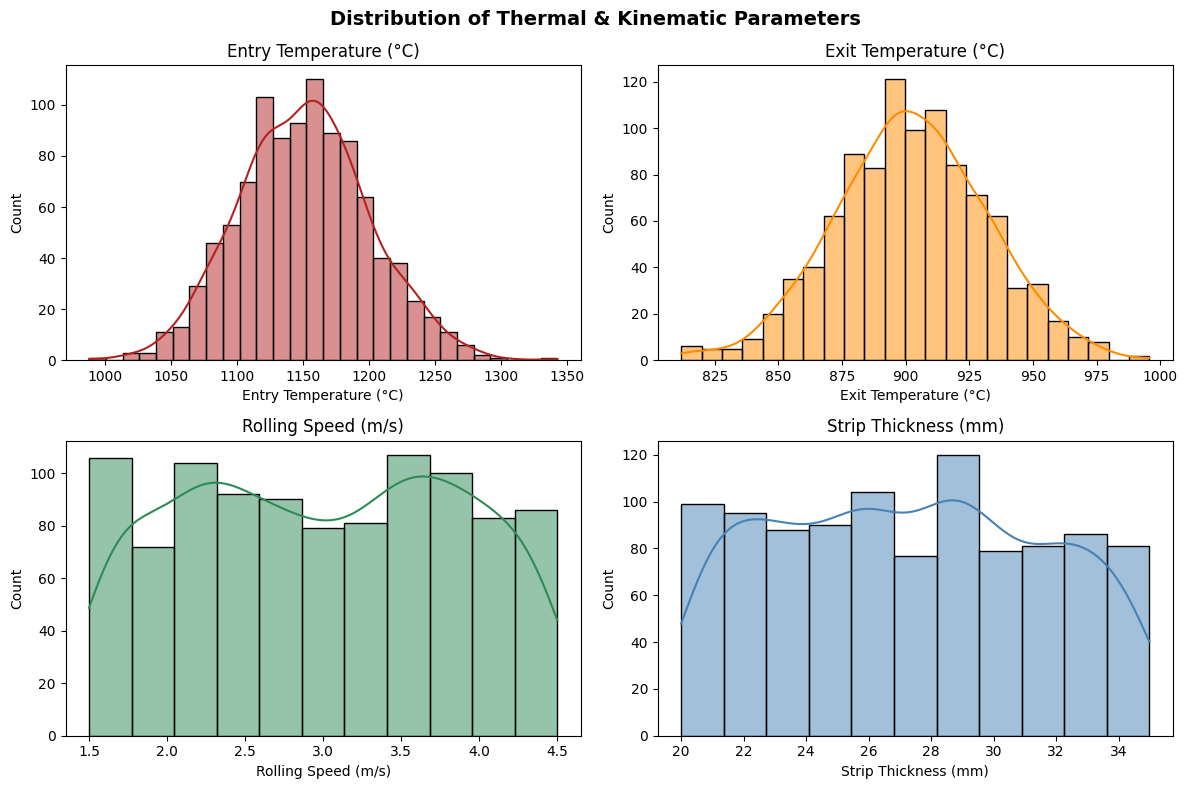

In [20]:
# Histograms with KDE for Thermal & Kinematic Parameters
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Distribution of Thermal & Kinematic Parameters',fontsize=14,fontweight='bold')

sns.histplot(df['entry_temperature'],kde=True,ax=axes[0, 0],color='firebrick')
axes[0, 0].set_title('Entry Temperature (°C)')
axes[0, 0].set_xlabel('Entry Temperature (°C)')

sns.histplot(df['exit_temperature'], kde=True, ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Exit Temperature (°C)')
axes[0, 1].set_xlabel('Exit Temperature (°C)')

sns.histplot(df['rolling_speed'], kde=True, ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Rolling Speed (m/s)')
axes[1, 0].set_xlabel('Rolling Speed (m/s)')

sns.histplot(df['strip_thickness'], kde=True, ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Strip Thickness (mm)')
axes[1, 1].set_xlabel('Strip Thickness (mm)')

plt.tight_layout()
plt.show()

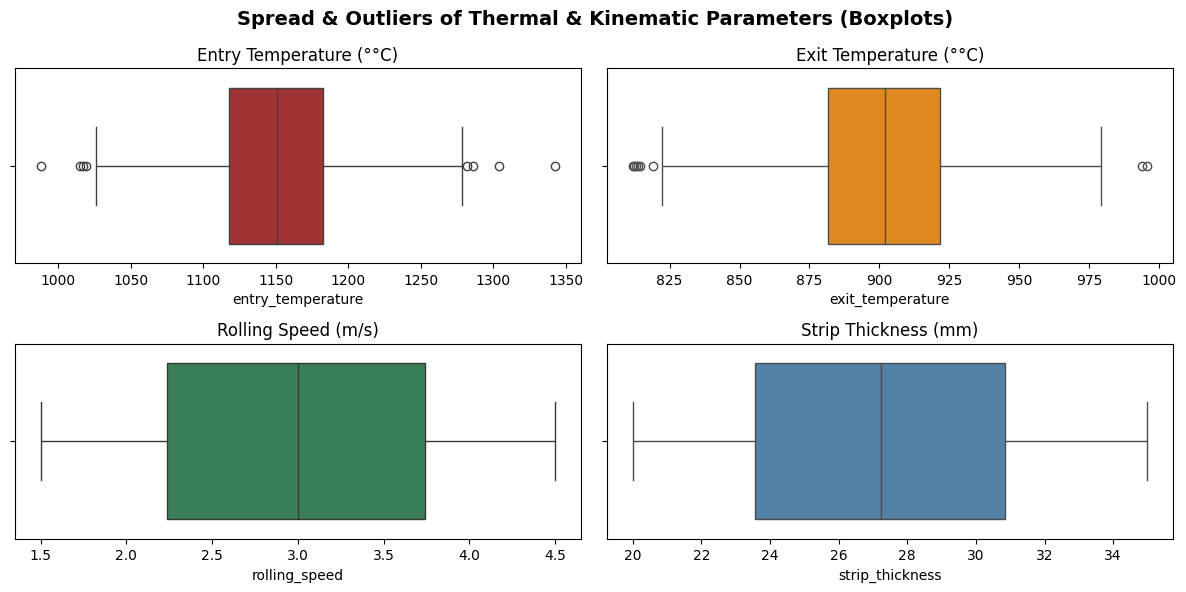

In [23]:
# Boxplots for Thermal & Kinematic Parameters
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Spread & Outliers of Thermal & Kinematic Parameters (Boxplots)', fontsize=14, fontweight='bold')

sns.boxplot(x=df['entry_temperature'], ax=axes[0, 0], color='firebrick')
axes[0, 0].set_title('Entry Temperature (°°C)')

sns.boxplot(x=df['exit_temperature'], ax=axes[0, 1], color='darkorange')
axes[0, 1].set_title('Exit Temperature (°°C)')

sns.boxplot(x=df['rolling_speed'], ax=axes[1, 0], color='seagreen')
axes[1, 0].set_title('Rolling Speed (m/s)')

sns.boxplot(x=df['strip_thickness'], ax=axes[1, 1], color='steelblue')
axes[1, 1].set_title('Strip Thickness (mm)')

plt.tight_layout()
plt.show()

#### Observations: Thermal & Kinematic Variables
- **Entry Temperature**: Displays a symmetric, bell-shaped distribution centered around ~1150 °C (min: ~988 °C, max: ~1343 °C). The boxplot highlights minor tail points beyond ~1280 °C and below ~1000 °C.
- **Exit Temperature**: Centered near ~902 °C with a narrow distribution spanning from ~812 °C to ~996 °C.
- **Rolling Speed**: Fairly uniform distribution spanning 1.50 m/s to 4.50 m/s , no extreme outliers.
- **Strip Thickness**: Evenly distributed between 20.0 mm and 35.0 mm with a median of 27.24 mm.

### 2.2 Deformation Mechanics, Geometry & Equipment Parameters
Next, we examine `deformation_resistance`, `friction_coefficient`, `roll_diameter`, `reduction_ratio`, `strain_rate`, and `bending_force`.

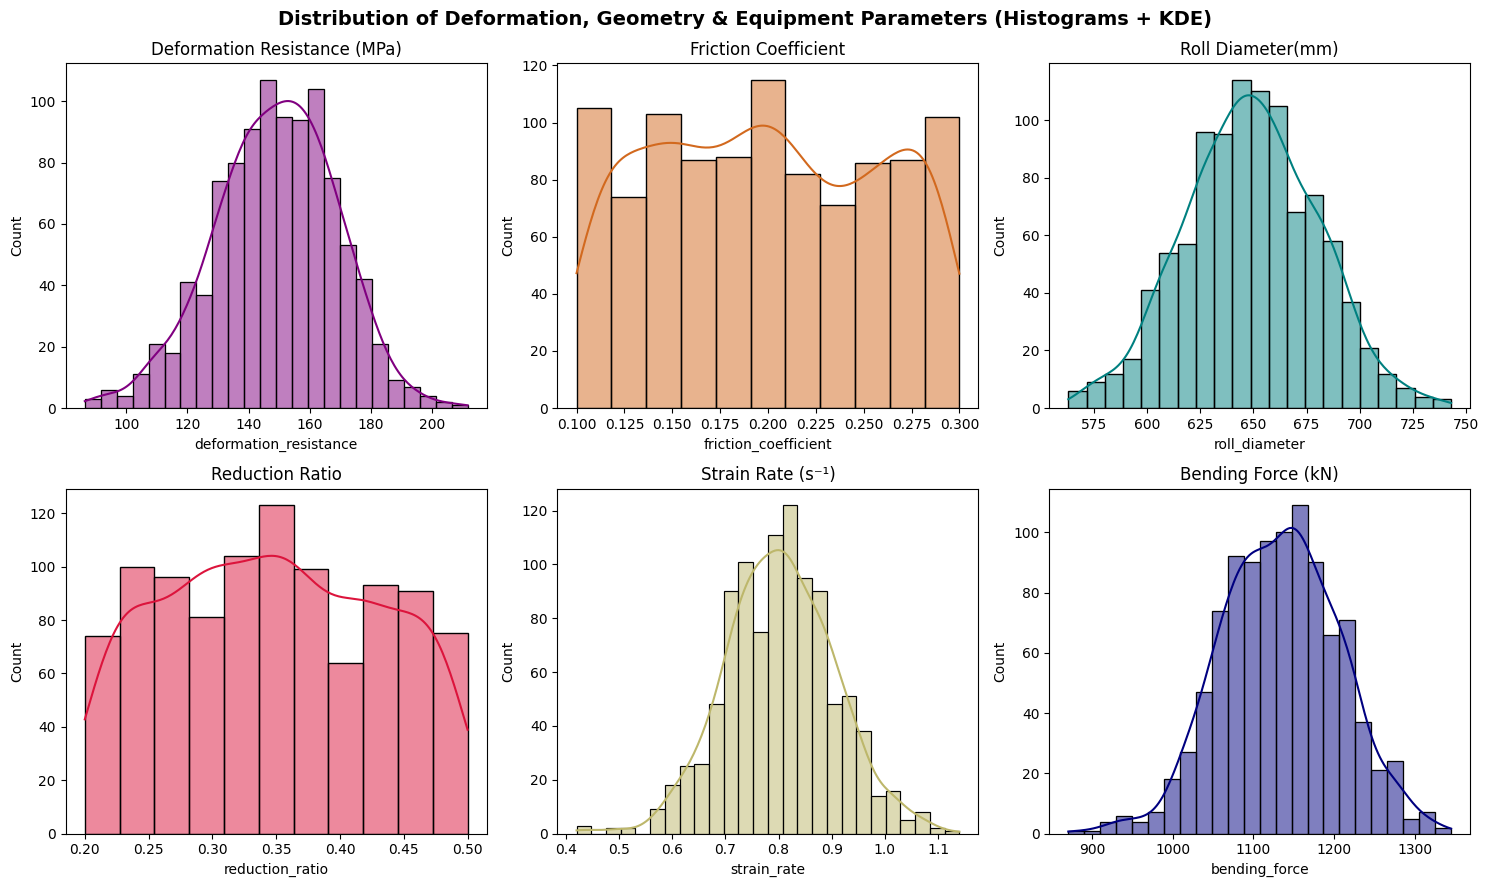

In [21]:
# Histograms with KDE for Deformation, Geometry & Equipment Parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('Distribution of Deformation, Geometry & Equipment Parameters (Histograms + KDE)', fontsize=14, fontweight='bold')

sns.histplot(df['deformation_resistance'],kde=True,ax=axes[0, 0],color='purple')
axes[0, 0].set_title('Deformation Resistance (MPa)')

sns.histplot(df['friction_coefficient'],kde=True,ax=axes[0, 1],color='chocolate')
axes[0, 1].set_title('Friction Coefficient')

sns.histplot(df['roll_diameter'],kde=True,ax=axes[0, 2],color='teal')
axes[0, 2].set_title('Roll Diameter(mm)')

sns.histplot(df['reduction_ratio'], kde=True, ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Reduction Ratio')

sns.histplot(df['strain_rate'], kde=True, ax=axes[1, 1], color='darkkhaki')
axes[1, 1].set_title('Strain Rate (s⁻¹)')

sns.histplot(df['bending_force'], kde=True, ax=axes[1, 2], color='navy')
axes[1, 2].set_title('Bending Force (kN)')

plt.tight_layout()
plt.show()

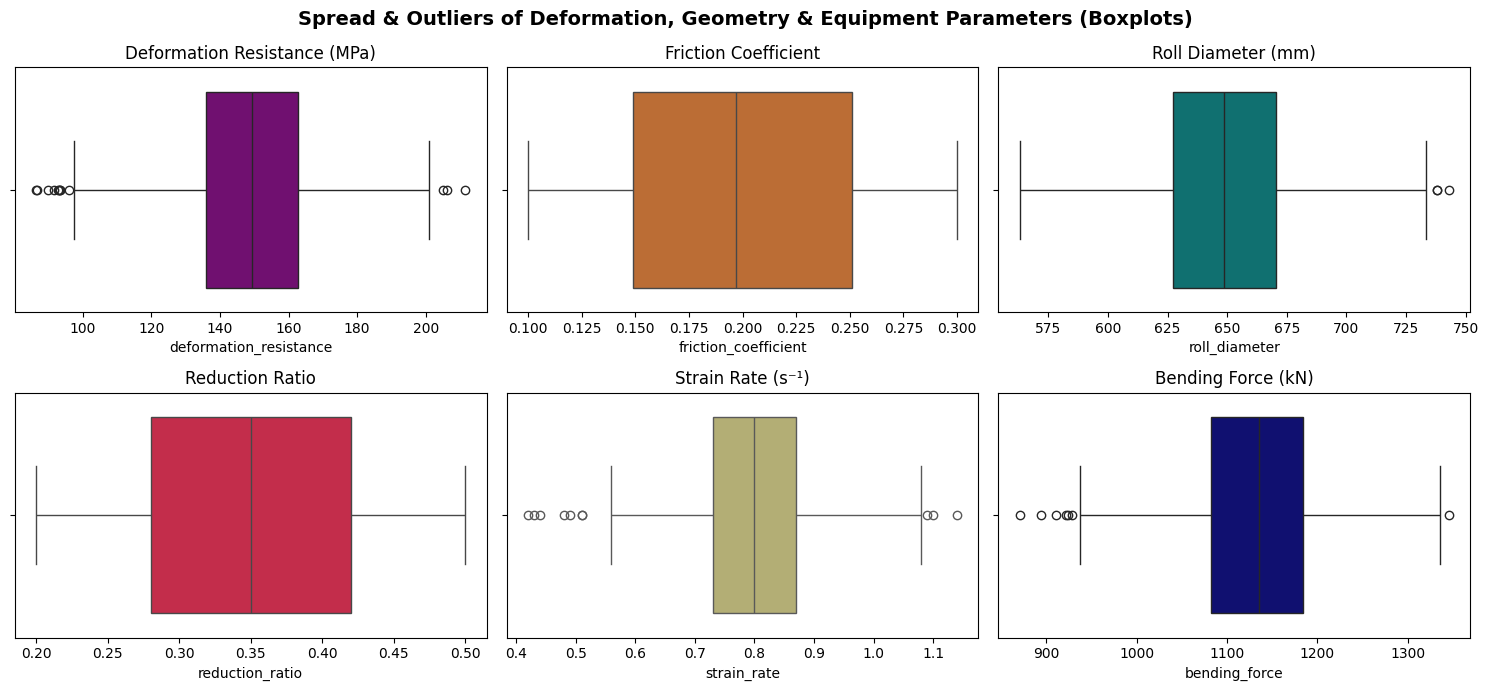

In [22]:
# Boxplots for Deformation, Geometry & Equipment Parameters
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Spread & Outliers of Deformation, Geometry & Equipment Parameters (Boxplots)', fontsize=14, fontweight='bold')

sns.boxplot(x=df['deformation_resistance'], ax=axes[0, 0], color='purple')
axes[0, 0].set_title('Deformation Resistance (MPa)')

sns.boxplot(x=df['friction_coefficient'], ax=axes[0, 1], color='chocolate')
axes[0, 1].set_title('Friction Coefficient')

sns.boxplot(x=df['roll_diameter'], ax=axes[0, 2], color='teal')
axes[0, 2].set_title('Roll Diameter (mm)')

sns.boxplot(x=df['reduction_ratio'], ax=axes[1, 0], color='crimson')
axes[1, 0].set_title('Reduction Ratio')

sns.boxplot(x=df['strain_rate'], ax=axes[1, 1], color='darkkhaki')
axes[1, 1].set_title('Strain Rate (s⁻¹)')

sns.boxplot(x=df['bending_force'], ax=axes[1, 2], color='navy')
axes[1, 2].set_title('Bending Force (kN)')

plt.tight_layout()
plt.show()

#### Observations: Deformation, Geometry & Equipment Parameters
- **Deformation Resistance**: Symmetrically distributed around ~149.5 MPa (range ~86.5 MPa to ~211.5 MPa).
- **Friction Coefficient**: Spans smoothly between 0.10 and 0.30 with a peak near 0.20.
- **Roll Diameter**: Centered at ~648.6 mm (range ~563 mm to ~743 mm).
- **Reduction Ratio**: Uniformly distributed across 0.20 (20% reduction) to 0.50 (50% reduction).
- **Strain Rate**: Symmetrically distributed around ~0.80 s⁻¹ (range 0.42 s⁻¹ to 1.14 s⁻¹).
- **Bending Force**: Bell-shaped distribution centered around ~1135 kN (range ~870.8 kN to ~1345.3 kN).

### 2.3 Categorical Variables Frequency Analysis
lets analyze the category frequencies for `material_grade` and `lubrication_type` using count plots labeled with actual categorical names.

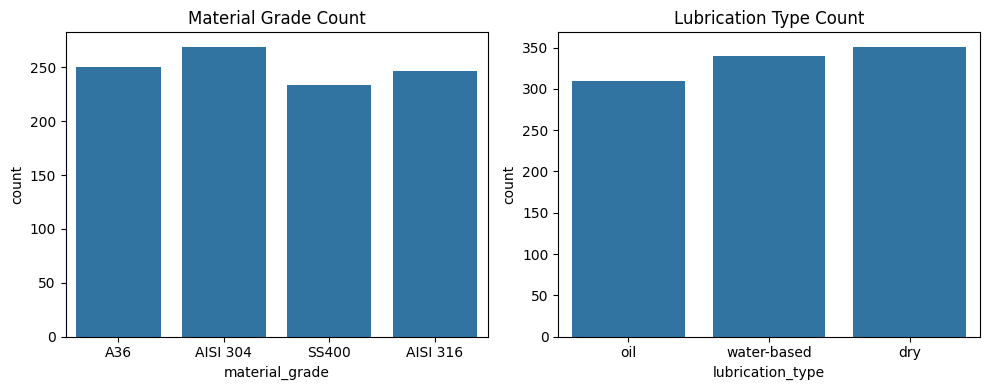

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.countplot(data=df, x='material_grade', ax=axes[0])
axes[0].set_title('Material Grade Count')

sns.countplot(data=df, x='lubrication_type', ax=axes[1])
axes[1].set_title('Lubrication Type Count')

plt.tight_layout()
plt.show()

In [26]:
df['lubrication_type'].value_counts()

lubrication_type
dry            351
water-based    340
oil            309
Name: count, dtype: int64

In [27]:
df['material_grade'].value_counts()

material_grade
AISI 304    269
A36         250
AISI 316    247
SS400       234
Name: count, dtype: int64

#### Observations: Categorical Variables
- **Material Grade**: `AISI 304` (269), `A36` (250), `AISI 316` (247), `SS400` (234). All 4 steel grades are represented in roughly equal proportions (~23% to 27% each).
- **Lubrication Type**: `dry` (351), `water-based` (340), `oil` (309). All 3 lubrication conditions are well represented across the dataset (~31% to 35% each).

### Stage 2 Summary
- All 10 continuous process parameters exhibit well-defined, continuous distributions spanning realistic industrial operational limits.
- Outliers identified in boxplots are few and lie within physical boundaries.
- Categorical classes are balanced across grades and lubrication methods.

## Stage 3: Bivariate / Process Relationship Analysis

In Stage 3, lets examine paired relationships between key hot strip rolling parameters. We analyze how thermal parameters interact and how process inputs (reduction ratio, deformation resistance, friction, rolling speed, strip thickness, roll diameter, strain rate, material grade, lubrication) relate to equipment loading (**`bending_force`**).



### 3.1 Bivariate Numerical Relationships & Scatter Plot Analysis
We construct scatter plots for 8 primary pairs of numerical process parameters to examine linear, non-linear, or weak associations.

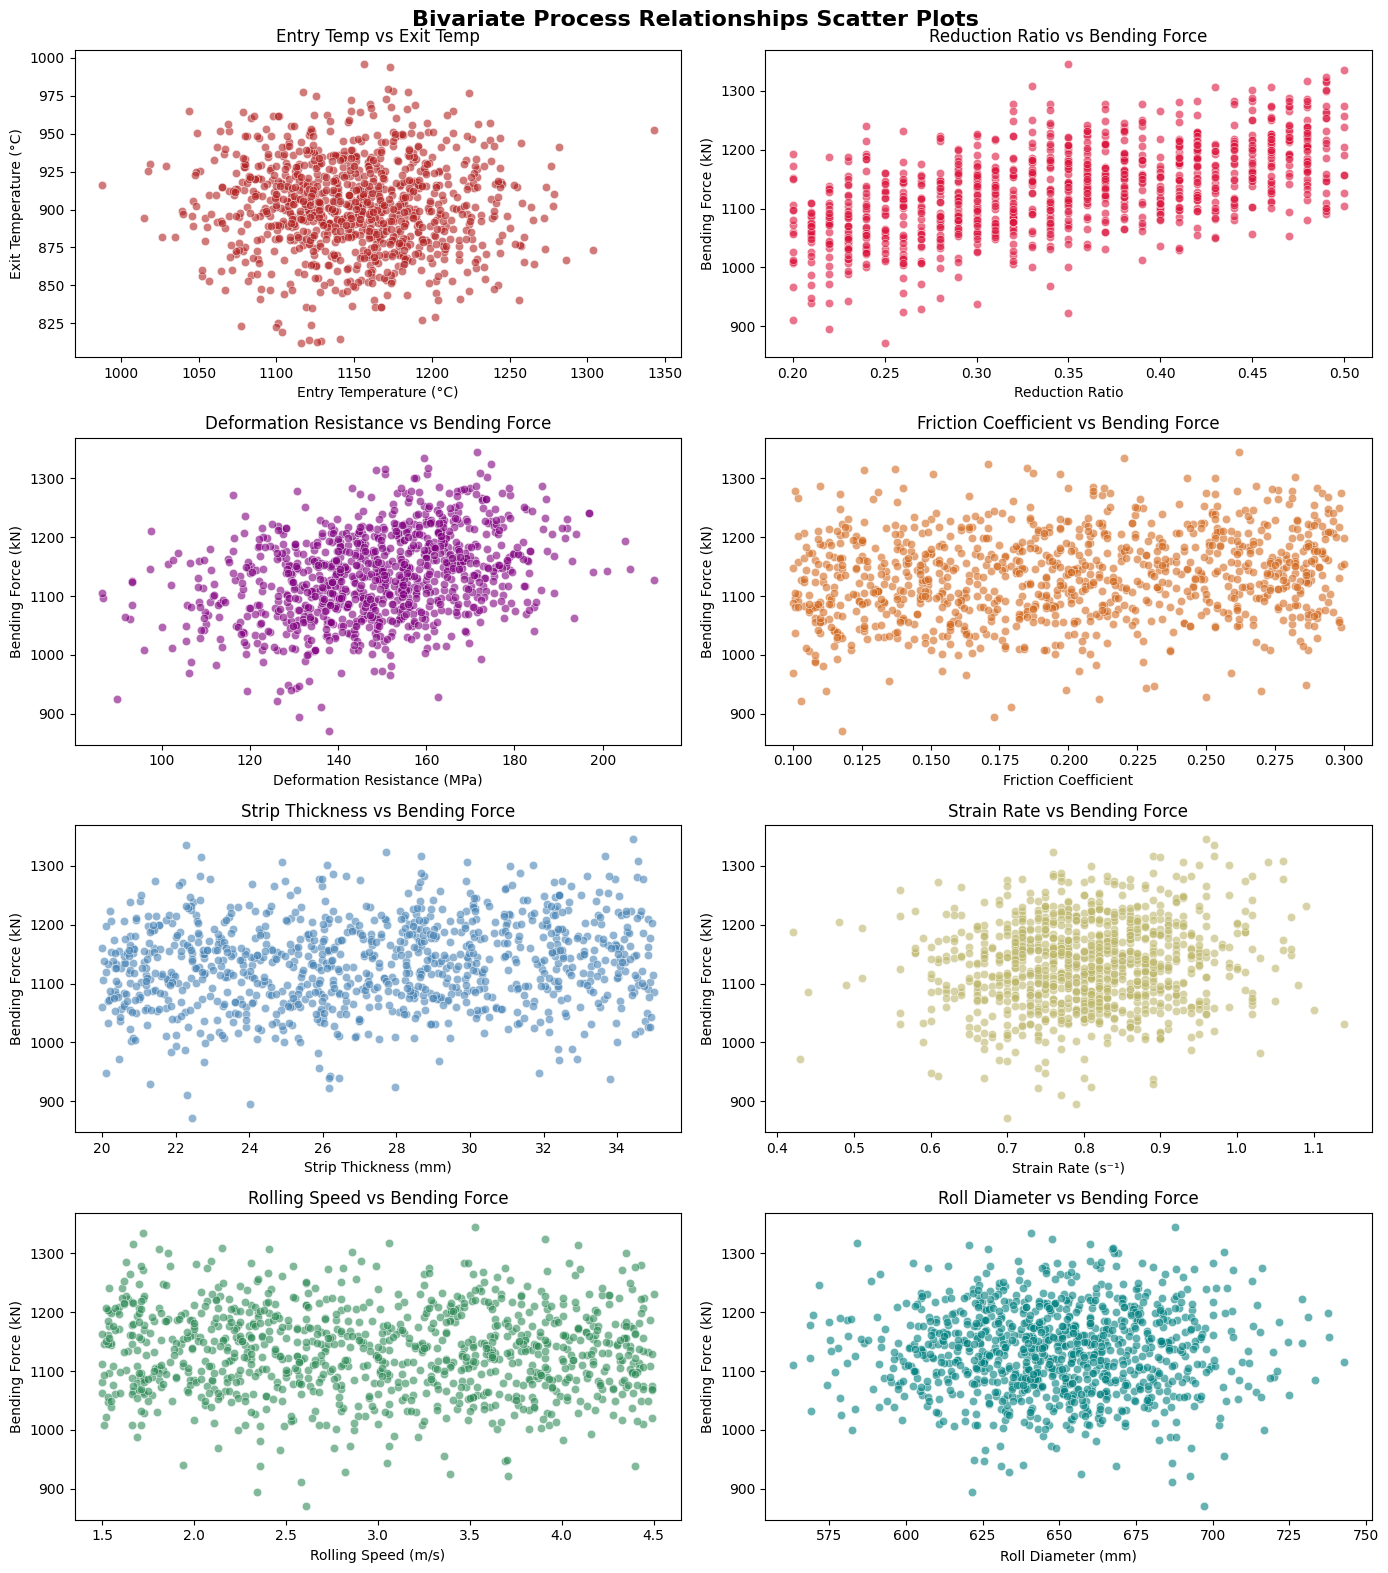

In [28]:
# Scatter plots of key process relationships
fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Bivariate Process Relationships Scatter Plots', fontsize=16, fontweight='bold')

# 1. entry_temperature vs exit_temperature
sns.scatterplot(data=df, x='entry_temperature', y='exit_temperature', ax=axes[0, 0], color='firebrick', alpha=0.6)
axes[0, 0].set_title('Entry Temp vs Exit Temp')
axes[0, 0].set_xlabel('Entry Temperature (°C)')
axes[0, 0].set_ylabel('Exit Temperature (°C)')

# 2. reduction_ratio vs bending_force
sns.scatterplot(data=df, x='reduction_ratio', y='bending_force', ax=axes[0, 1], color='crimson', alpha=0.6)
axes[0, 1].set_title('Reduction Ratio vs Bending Force')
axes[0, 1].set_xlabel('Reduction Ratio')
axes[0, 1].set_ylabel('Bending Force (kN)')

# 3. deformation_resistance vs bending_force
sns.scatterplot(data=df, x='deformation_resistance', y='bending_force', ax=axes[1, 0], color='purple', alpha=0.6)
axes[1, 0].set_title('Deformation Resistance vs Bending Force')
axes[1, 0].set_xlabel('Deformation Resistance (MPa)')
axes[1, 0].set_ylabel('Bending Force (kN)')

# 4. friction_coefficient vs bending_force
sns.scatterplot(data=df, x='friction_coefficient', y='bending_force', ax=axes[1, 1], color='chocolate', alpha=0.6)
axes[1, 1].set_title('Friction Coefficient vs Bending Force')
axes[1, 1].set_xlabel('Friction Coefficient')
axes[1, 1].set_ylabel('Bending Force (kN)')

# 5. strip_thickness vs bending_force
sns.scatterplot(data=df, x='strip_thickness', y='bending_force', ax=axes[2, 0], color='steelblue', alpha=0.6)
axes[2, 0].set_title('Strip Thickness vs Bending Force')
axes[2, 0].set_xlabel('Strip Thickness (mm)')
axes[2, 0].set_ylabel('Bending Force (kN)')

# 6. strain_rate vs bending_force
sns.scatterplot(data=df, x='strain_rate', y='bending_force', ax=axes[2, 1], color='darkkhaki', alpha=0.6)
axes[2, 1].set_title('Strain Rate vs Bending Force')
axes[2, 1].set_xlabel('Strain Rate (s⁻¹)')
axes[2, 1].set_ylabel('Bending Force (kN)')

# 7. rolling_speed vs bending_force
sns.scatterplot(data=df, x='rolling_speed', y='bending_force', ax=axes[3, 0], color='seagreen', alpha=0.6)
axes[3, 0].set_title('Rolling Speed vs Bending Force')
axes[3, 0].set_xlabel('Rolling Speed (m/s)')
axes[3, 0].set_ylabel('Bending Force (kN)')

# 8. roll_diameter vs bending_force
sns.scatterplot(data=df, x='roll_diameter', y='bending_force', ax=axes[3, 1], color='teal', alpha=0.6)
axes[3, 1].set_title('Roll Diameter vs Bending Force')
axes[3, 1].set_xlabel('Roll Diameter (mm)')
axes[3, 1].set_ylabel('Bending Force (kN)')

plt.tight_layout()
plt.show()

Overall, these graphs show that bending force depends on multiple interacting rolling parameters rather than any single variable. Some variables show a general increasing trend, but the large scatter means that other factors like temperature, material grade, reduction, friction and strain rate also affect the force. So, bending force is a multivariable process outcome, which is why ML can be useful for its prediction.

### 3.2 Bending Force Comparison across Categorical Variables
We analyze the distribution of `bending_force` across different steel grades (`material_grade`) and cooling/lubrication methods (`lubrication_type`).
*(Note: Encoded columns `material_grade_encoded` and `lubrication_type_encoded` are excluded from visualizations).* 

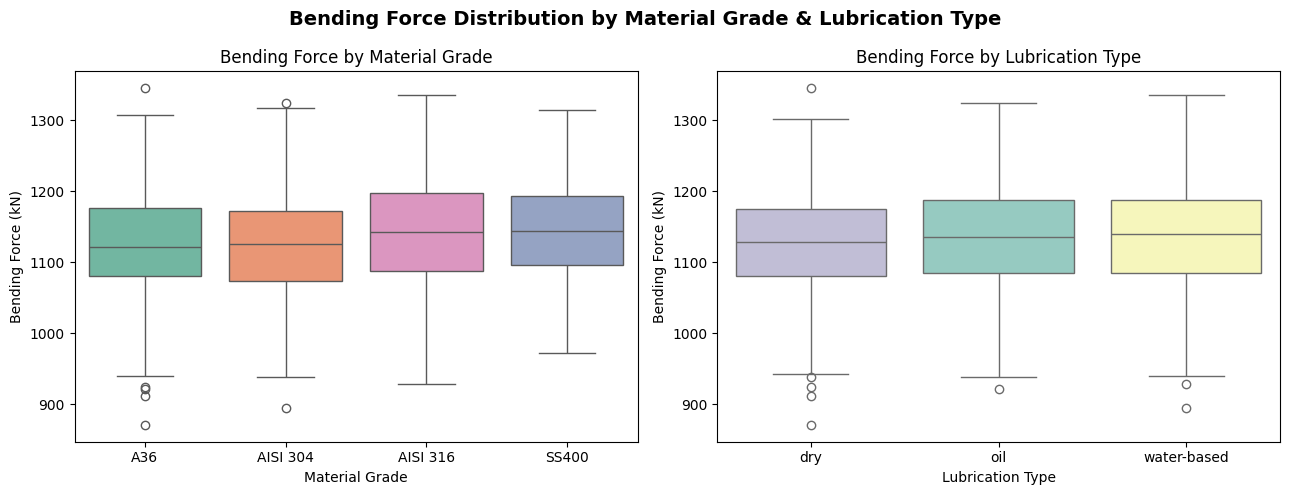

In [31]:
# Bending Force distribution across °Categorical Variables
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Bending Force Distribution by Material Grade & Lubrication Type', fontsize=14, fontweight='bold')

# Bending Force vs Material Grade
sns.boxplot(data=df, x='material_grade', y='bending_force', hue='material_grade', legend=False, ax=axes[0], palette='Set2', order=['A36', 'AISI 304', 'AISI 316', 'SS400'])
axes[0].set_title('Bending Force by Material Grade')
axes[0].set_xlabel('Material Grade')
axes[0].set_ylabel('Bending Force (kN)')

# Bending Force vs Lubrication Type
sns.boxplot(data=df, x='lubrication_type', y='bending_force', hue='lubrication_type', legend=False, ax=axes[1], palette='Set3', order=['dry', 'oil', 'water-based'])
axes[1].set_title('Bending Force by Lubrication Type')
axes[1].set_xlabel('Lubrication Type')
axes[1].set_ylabel('Bending Force (kN)')

plt.tight_layout()
plt.show()

#### Observations: Categorical Comparisons
  *The interquartile ranges (IQRs) across all four material grades overlap substantially, showing similar overall bending force ranges (~870 kN to ~1345 kN).*

  *All three lubrication conditions exhibit broad, overlapping boxplot ranges, indicating consistent overall force ranges regardless of lubrication method.* 

### Stage 3 Summary
- `reduction_ratio` and `deformation_resistance` show the clearest positive visual trends with `bending_force`.
- Parameters such as `rolling_speed`, `entry_temperature`, and `roll_diameter` show high dispersion and little to no linear association with bending force.
- Across categorical steel grades and lubrication methods, bending force distributions remain broadly consistent with heavy overlap in ranges.

## Stage 4: Correlation Analysis

In Stage 4, lets perform a Pearson correlation analysis across all 10 genuine numerical process variables and equipment loading (`bending_force`).



### Understanding Pearson Correlation

- **What Pearson Correlation ($r$) Represents**:
  The Pearson correlation coefficient measures the strength and direction of a **linear relationship** between two numerical variables:
  - $r = +1.0$: Perfect positive linear correlation
  - $r = 0.0$: No linear correlation
  - $r = -1.0$: Perfect negative linear correlation


### 4.1 Pearson Correlation Matrix Calculation
lets isolate the 10 numerical process columns and calculate the pairwise Pearson correlation matrix.

In [29]:
numerical_cols = [
    'entry_temperature', 'exit_temperature', 'rolling_speed', 'strip_thickness',
    'deformation_resistance', 'friction_coefficient', 'roll_diameter',
    'reduction_ratio', 'strain_rate', 'bending_force'
]

#  Pearson correlation matrix---:
corr_matrix = df[numerical_cols].corr()
corr_matrix.round(2)

,entry_temperature,exit_temperature,rolling_speed,strip_thickness,deformation_resistance,friction_coefficient,roll_diameter,reduction_ratio,strain_rate,bending_force
entry_temperature,1.00,-0.04,0.06,-0.03,-0.03,-0.02,0.01,-0.07,-0.01,0.13
exit_temperature,-0.04,1.00,0.03,0.04,-0.02,0.01,-0.05,0.00,0.01,0.12
rolling_speed,0.06,0.03,1.00,-0.01,0.03,-0.05,-0.02,-0.00,-0.02,-0.05
strip_thickness,-0.03,0.04,-0.01,1.00,0.02,0.00,-0.01,0.01,-0.04,0.14
deformation_resistance,-0.03,-0.02,0.03,0.02,1.00,-0.01,0.01,0.02,0.02,0.34
friction_coefficient,-0.02,0.01,-0.05,0.00,-0.01,1.00,-0.04,0.06,-0.01,0.18
roll_diameter,0.01,-0.05,-0.02,-0.01,0.01,-0.04,1.00,-0.02,-0.01,0.00
reduction_ratio,-0.07,0.00,-0.00,0.01,0.02,0.06,-0.02,1.00,-0.03,0.58
strain_rate,-0.01,0.01,-0.02,-0.04,0.02,-0.01,-0.01,-0.03,1.00,0.12
bending_force,0.13,0.12,-0.05,0.14,0.34,0.18,0.00,0.58,0.12,1.00


### 4.2 Correlation Heatmap


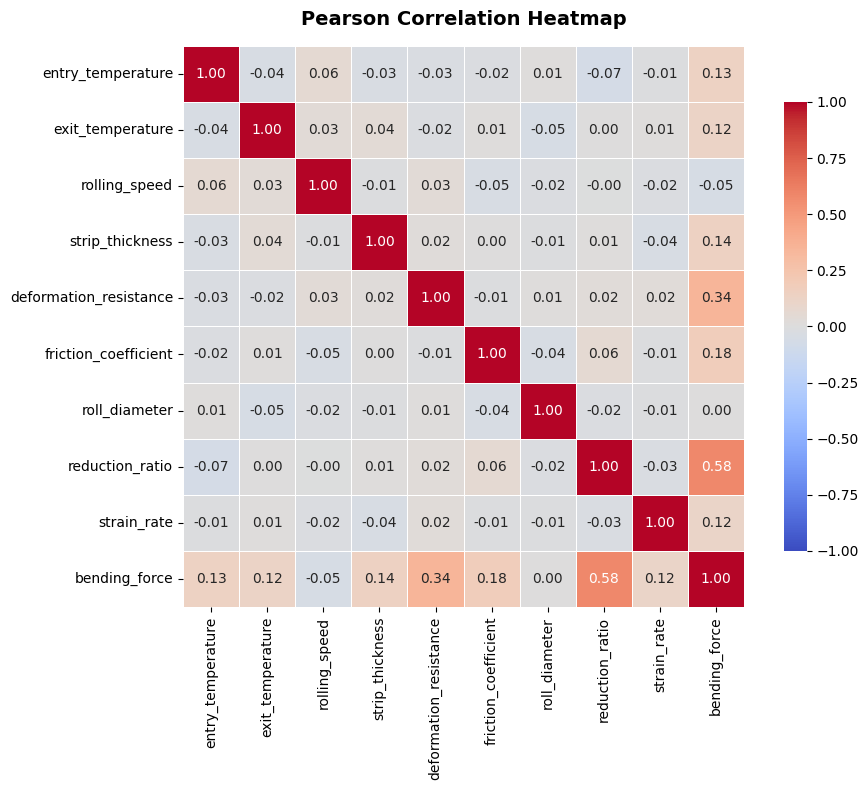

In [32]:
# Render Seaborn °Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt='.2f', 
            cmap='coolwarm', 
            vmin=-1, 
            vmax=1, 
            square=True, 
            linewidths=0.5, 
            cbar_kws={'shrink': 0.8})

plt.title('Pearson Correlation Heatmap', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

In [54]:
# ### 4.3 Detailed Correlation Findings

# #### 1. Correlations involving `bending_force`:
# - **Strongest Positive Correlation**: **`reduction_ratio`** ($r = +0.58$)
#   - Reduction ratio exhibits the strongest positive linear association with bending force.
# - **Moderate Positive Correlation**: **`deformation_resistance`** ($r = +0.34$)
#   - Higher deformation resistance shows a moderate positive correlation with bending force.
# - **Weak Positive Correlations**: 
#   - `friction_coefficient` ($r = +0.18$)
#   - `strip_thickness` ($r = +0.14$)
#   - `entry_temperature` ($r = +0.13$)
#   - `exit_temperature` ($r = +0.12$)
#   - `strain_rate` ($r = +0.12$)
# - **Strongest Negative Correlation**: **`rolling_speed`** ($r = -0.05$)
#   - Rolling speed has the lowest (slight negative) correlation with bending force, though it is near zero.
# - **Near-Zero Correlation**: **`roll_diameter`** ($r = +0.001$)
#   - Virtually zero linear correlation with bending force.

# #### 2. Correlations among Process Parameters:
# - All pairwise correlations between the input process parameters themselves are extremely low ($|r| < 0.07$).
# - *Example*: `entry_temperature` vs `reduction_ratio` ($r = -0.07$), `rolling_speed` vs `entry_temperature` ($r = +0.06$).
# - This indicates that the input operating parameters in this dataset vary independently without significant multicollinearity.

# ### Stage 4 Summary
# - `reduction_ratio` ($r = 0.58$) and `deformation_resistance` ($r = 0.34$) are the key parameters showing notable positive linear alignment with `bending_force`.
# - Input process parameters show near-zero mutual correlation ($|r| < 0.07$), confirming parameter independence in the dataset.

now lets also analyze material grade wise

<Axes: xlabel='reduction_ratio', ylabel='bending_force'>

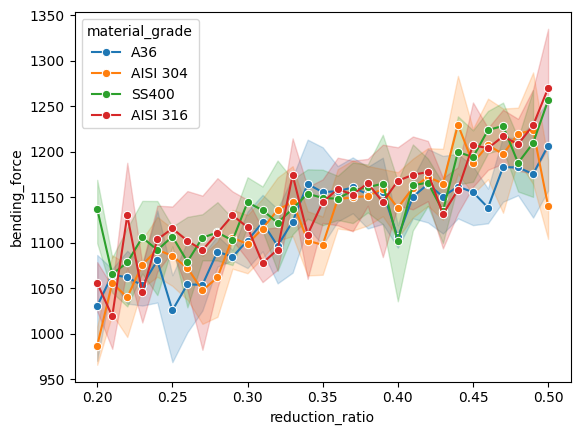

In [35]:
sns.lineplot(data=df,x='reduction_ratio',y='bending_force',hue='material_grade',marker='o',estimator='mean')

this means with inc red_ratio ,avg of bending force is normally increasing 

now lets also see the relation bw entry temp and grade 

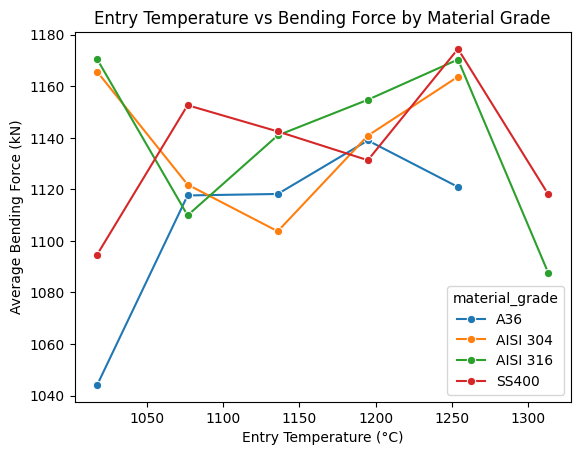

In [39]:
df['temp_bin'] = pd.cut(
    df['entry_temperature'],
    bins=6
)

temp_avg = (
    df.groupby(['temp_bin', 'material_grade'], observed=True)['bending_force']
      .mean()
      .reset_index()
)

temp_avg['temp_mid'] = temp_avg['temp_bin'].apply(lambda x: x.mid)

sns.lineplot(
    data=temp_avg,
    x='temp_mid',
    y='bending_force',
    hue='material_grade',
    marker='o'
)

plt.xlabel('Entry Temperature (°C)')
plt.ylabel('Average Bending Force (kN)')
plt.title('Entry Temperature vs Bending Force by Material Grade')
plt.show()

Entry temperature alone does not show a clear relationship with bending force in this dataset; its effect is likely masked by other interacting rolling parameters.

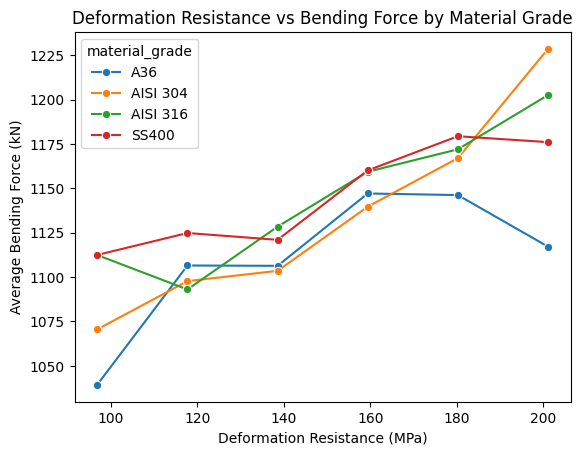

In [41]:
df['dr_bin'] = pd.cut(df['deformation_resistance'], bins=6)

dr_avg = (
    df.groupby(['dr_bin', 'material_grade'], observed=True)['bending_force']
      .mean()
      .reset_index()
)

dr_avg['dr_mid'] = dr_avg['dr_bin'].apply(lambda x: x.mid)

sns.lineplot(
    data=dr_avg,
    x='dr_mid',
    y='bending_force',
    hue='material_grade',
    marker='o',
    errorbar=None
)

plt.xlabel('Deformation Resistance (MPa)')
plt.ylabel('Average Bending Force (kN)')
plt.title('Deformation Resistance vs Bending Force by Material Grade')
plt.show()

lets check why there is a sudden drop for A36 

In [44]:
df[df['material_grade'] == 'A36'].groupby(
    pd.cut(df[df['material_grade'] == 'A36']['deformation_resistance'], bins=6)
)['bending_force'].agg(['count', 'mean'])

C:\Users\Pankaj Agarwal\AppData\Local\Temp\ipykernel_35048\2605250854.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['material_grade'] == 'A36'].groupby(


,count,mean
deformation_resistance,,
"(86.47, 106.54]",4,1041.702500
"(106.54, 126.49]",28,1099.268214
"(126.49, 146.44]",85,1107.038706
"(146.44, 166.39]",94,1144.253085
"(166.39, 186.34]",35,1141.522286
"(186.34, 206.29]",4,1132.082500


means the last bin has only 4 data points so we cant conclude anything 

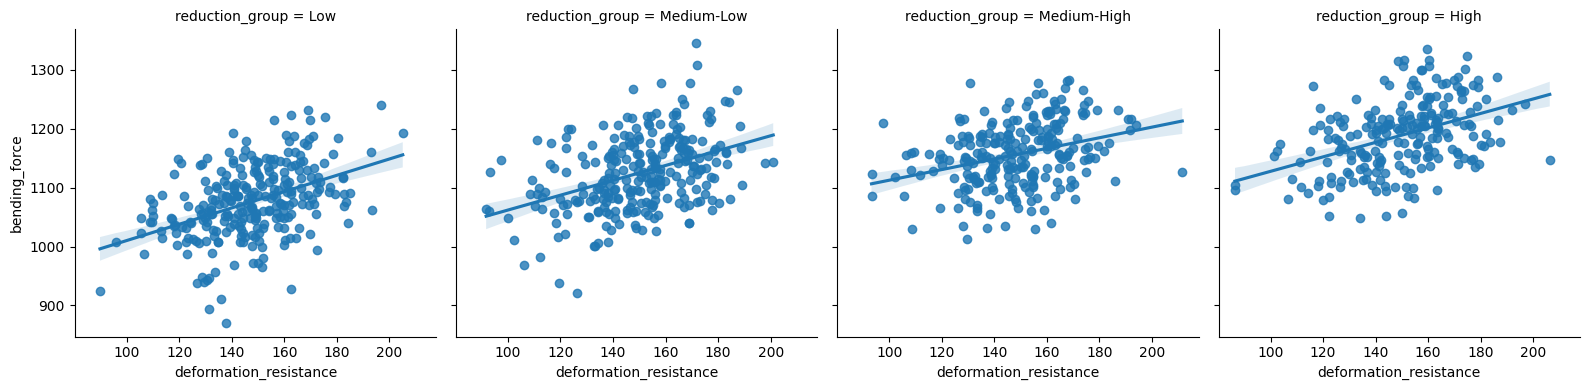

In [45]:
df['reduction_group'] = pd.qcut(
    df['reduction_ratio'],
    q=4,
    labels=['Low', 'Medium-Low', 'Medium-High', 'High']
)

sns.lmplot(
    data=df,
    x='deformation_resistance',
    y='bending_force',
    col='reduction_group',
    height=4,
    aspect=1
)

plt.show()

here we can see that if we r keeping red_ratio the same,and then inc def_resistance then bending force is incereasing,so bending force is affected by deformation resistance as well

C:\Users\Pankaj Agarwal\AppData\Local\Temp\ipykernel_35048\2968479328.py:4: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = df.pivot_table(


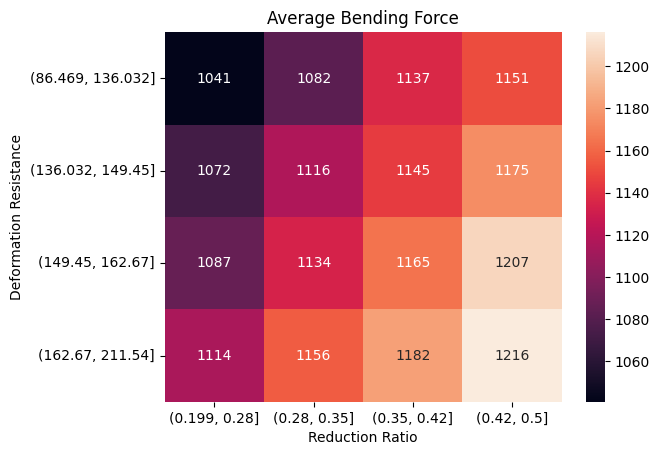

In [46]:
df['reduction_group'] = pd.qcut(df['reduction_ratio'], 4)
df['dr_group'] = pd.qcut(df['deformation_resistance'], 4)

pivot = df.pivot_table(
    values='bending_force',
    index='dr_group',
    columns='reduction_group',
    aggfunc='mean'
)

sns.heatmap(pivot, annot=True, fmt='.0f')
plt.title('Average Bending Force')
plt.xlabel('Reduction Ratio')
plt.ylabel('Deformation Resistance')
plt.show()

above heatmap means Bending force increases when both reduction ratio and deformation resistance increase. This shows that higher deformation and greater resistance of the material together require more force during rolling.

## Stage 5: Process and Metallurgical Interpretation

In this section, we provide a domain-specific metallurgical and process interpretation of the major observations identified during EDA.

For each key operational parameter, we clearly distinguish between:
1. **Dataset Observation**: What is empirically observed in the dataset and statistics.
2. **Possible Process Interpretation**: Theoretical metallurgical/rolling mill explanations corresponding to standard hot strip mill practice.

*Disclaimer: Process interpretations represent plausible physical explanations based on hot rolling principles and do not assert absolute causation from correlation alone.*

### 5.1 Reduction Ratio vs. Bending Force

- **Dataset Observation**:
  The dataset exhibits a moderate-to-strong positive linear correlation ($r = +0.58$) between `reduction_ratio` (0.20 to 0.50) and `bending_force` (870.8 kN to 1345.3 kN).

- **Possible Process Interpretation**:
  In hot strip rolling mechanics, a higher reduction ratio corresponds to a larger thickness draft ($\Delta h = h_{in} - h_{out}$), which increases the contact length between the work rolls and the hot strip in the roll gap. This increases the total rolling load ($P$), leading to greater elastic roll deflection (bending) and strip crown. To maintain strip flatness and target profile, hydraulic roll bending systems must apply higher counter-bending forces.

### 5.2 Deformation Resistance vs. Bending Force

- **Dataset Observation**:
  `deformation_resistance` (86.5 MPa to 211.5 MPa) shows a moderate positive linear correlation ($r = +0.34$) with `bending_force`.

- **Possible Process Interpretation**:
  Deformation resistance reflects the mean flow stress ($\sigma_m$) of the hot steel material during plastic deformation. Higher resistance to plastic flow increases the specific roll pressure required to compress the strip. Increased roll pressure induces higher bending moments across the roll body, which is balanced in mill automation by increasing hydraulic roll bending forces.

### 5.3 Friction Coefficient & Lubrication Type

- **Dataset Observation**:
  `friction_coefficient` (0.10 to 0.30) displays a weak positive correlation ($r = +0.18$) with `bending_force`. Boxplot distributions of `bending_force` across `lubrication_type` (`dry`, `oil`, `water-based`) show heavy overlap with similar average forces (~1125 kN to ~1139 kN).

- **Possible Process Interpretation**:
  At the roll-strip contact, higher friction increases the resistance to rolling, so the required rolling force increases slightly. Lubricants like oil and water-based emulsions reduce friction and roll wear, but the actual bending force also depends on strip thickness, reduction, and mill settings.

### 5.4 Thermal Parameters (Entry and Exit Temperatures)

- **Dataset Observation**:
  `entry_temperature` (988 °C to 1343 °C) and `exit_temperature` (812 °C to 996 °C) show a near-zero correlation with each other ($r = -0.04$) and weak positive correlations with `bending_force` ($r = +0.13$ and $+0.12$).



### Stage 5 Summary
- **Primary Load Drivers**: `reduction_ratio` and `deformation_resistance` are the primary process parameters aligned with hydraulic roll `bending_force` in the dataset.


## Stage 6: Key Findings and Conclusion

### 6.1 Key Findings

Below is a summary of the 7 major findings supported directly by the Exploratory Data Analysis of the Hot Strip Rolling dataset:

1. **Complete Data Integrity & Stable Operating Windows**:
   The dataset contains **1,000 complete process records** with 0 missing values and 0 duplicate rows. Continuous variables span realistic industrial operating boundaries (e.g., entry temperature 988–1343 °C, exit temperature 812–996 °C, bending force 870.8–1345.3 kN).

2. **Reduction Ratio is the Primary Load Driver**:
   Thickness `reduction_ratio` exhibits the strongest positive linear correlation ($r = +0.58$) with `bending_force`. Higher thickness reduction ratios correlate with higher required bending forces to maintain strip flatness.

3. **Deformation Resistance Impacts Mill Loading**:
   `deformation_resistance` shows a moderate positive linear correlation ($r = +0.34$) with `bending_force`, illustrating how higher flow stress during plastic deformation increases required hydraulic roll bending forces.




### 6.2 Conclusion

#### Project Summary & Industrial Insights
- **What Was Analyzed**:
  This project performed a comprehensive Exploratory Data Analysis (EDA) on **1,000 industrial process records** from a Hot Strip Mill (HSM). The analysis covered 14 process parameters capturing thermal dynamics, deformation mechanics, roll geometry, lubrication, material specifications, and hydraulic equipment loading.

- **Key Parameters & Observed Relationships**:
  The analysis established thickness `reduction_ratio` ($r = +0.58$) and `deformation_resistance` ($r = +0.34$) as the key process parameters positively aligned with hydraulic `bending_force`. In contrast, variables such as `rolling_speed` ($r = -0.05$) and `roll_diameter` ($r = +0.001$) showed near-zero linear correlation with bending force.



--- 
